# Lagrange multipliers: from symbolic equations to numerical solutions

Lagrange multipliers locate stationary points of a function while enforcing one or more equality constraints. In this tutorial we solve two physical problems twice:

1. symbolically with **SymPy**, to expose all stationary candidates;
2. numerically with **SciPy**, to see how constrained optimization behaves in practice.

The examples progress from the maximum range of an ideal projectile to the equilibrium of a bead constrained by two surfaces.

## Learning objectives and setup

After working through this notebook, you should be able to:

- construct a Lagrangian for one or more equality constraints;
- use SymPy to find and classify stationary candidates;
- express the same problem using SciPy constraints;
- check feasibility and compare symbolic and numerical results;
- explain why a numerical optimizer reporting success is not proof of a global optimum.

**Prerequisites:** partial derivatives, vectors, and basic Python. No specialist mechanics knowledge is required.

Run the notebook from the repository root with `pixi run lab`. The notebook uses only the default repository environment and does not install packages. Its small outputs and figures are intentionally retained because they are part of the tutorial.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import display
from scipy.optimize import Bounds, LinearConstraint, NonlinearConstraint, minimize

sp.init_printing()
np.set_printoptions(precision=8, suppress=True)

## The method

Suppose that we want to minimize or maximize $f(\mathbf{x})$ subject to $m$ equality constraints

$$g_j(\mathbf{x})=0, \qquad j=1,\ldots,m.$$

Here $\mathbf{x}\in\mathbb{R}^n$ contains the unknowns. Introduce one multiplier $\lambda_j$ for each constraint and form

$$\mathcal{L}(\mathbf{x},\boldsymbol{\lambda}) = f(\mathbf{x}) + \sum_{j=1}^m \lambda_j g_j(\mathbf{x}).$$

At a regular constrained optimum, the necessary first-order conditions are

$$\nabla_{\mathbf{x}}\mathcal{L}=\mathbf{0}, \qquad g_j(\mathbf{x})=0.$$

Regular means that the gradients of the active constraints are linearly independent. Geometrically, the objective gradient lies in the span of the constraint gradients. These equations produce **candidates**, not a guarantee that a candidate is a minimum, a maximum, or global.

## Example 1: maximum range of an ideal projectile

A projectile is launched from and lands at the same height. We neglect air resistance and assume uniform gravitational acceleration $g>0$. Let $v_x$ and $v_y$ be the initial horizontal and vertical velocity components.

The time of flight is $2v_y/g$, so the horizontal range is

$$d(v_x,v_y)=v_x\frac{2v_y}{g}=\frac{2v_xv_y}{g}.$$

The product $v_xv_y$ therefore has a concrete meaning: $v_x$ controls horizontal progress, while $v_y$ controls time aloft. If the launch speed $v_0$ is fixed, then

$$v_x^2+v_y^2=v_0^2.$$

We maximize $d$ in the physical quadrant $v_x>0$, $v_y>0$.

In [2]:
v_x, v_y, lambda_1 = sp.symbols("v_x v_y lambda_1", real=True)
v_0, g = sp.symbols("v_0 g", positive=True)

projectile_range = 2 * v_x * v_y / g
speed_constraint = v_x**2 + v_y**2 - v_0**2

# The sign chosen for a multiplier is conventional.
L_projectile = projectile_range - lambda_1 * speed_constraint
projectile_equations = [
    sp.Eq(sp.diff(L_projectile, variable), 0)
    for variable in (v_x, v_y)
] + [sp.Eq(speed_constraint, 0)]

display(sp.Eq(sp.Symbol("L"), L_projectile))
display(*projectile_equations)

In [3]:
projectile_candidates = sp.solve(
    projectile_equations, (v_x, v_y, lambda_1), dict=True
)
projectile_candidates

In [4]:
physical_candidates = [
    candidate
    for candidate in projectile_candidates
    if candidate[v_x].is_positive and candidate[v_y].is_positive
]
projectile_solution = physical_candidates[0]
maximum_range = sp.simplify(projectile_range.subs(projectile_solution))
launch_angle = sp.simplify(sp.atan(projectile_solution[v_y] / projectile_solution[v_x]))

display(projectile_solution)
display(sp.Eq(sp.Symbol("d_max"), maximum_range))
display(sp.Eq(sp.Symbol("theta"), launch_angle))

SymPy returns four mathematical stationary points because the full circle includes velocity components of either sign. The physical assumptions select

$$v_x=v_y=\frac{v_0}{\sqrt{2}}, \qquad \theta=\frac{\pi}{4}, \qquad d_{\max}=\frac{v_0^2}{g}.$$

The other sign combinations describe motion in a different horizontal direction or an initially downward trajectory. The symbolic result is therefore not self-interpreting: the physical domain matters.

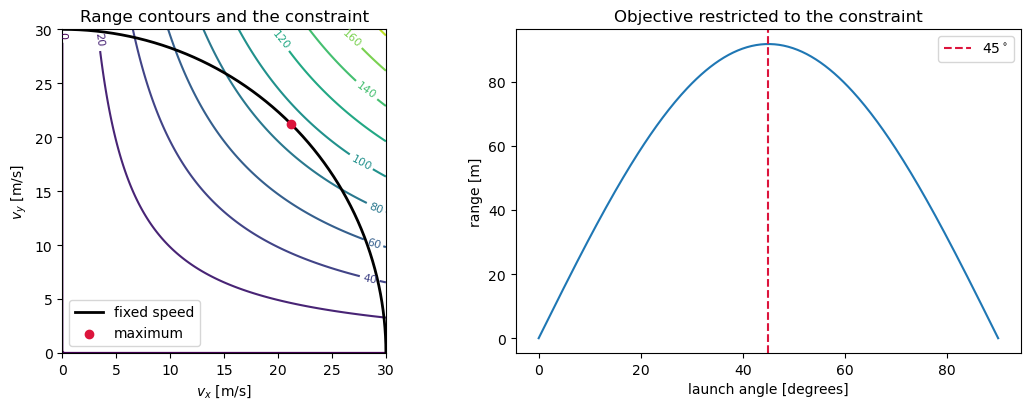

In [5]:
speed = 30.0  # m/s
gravity = 9.81  # m/s^2

component = np.linspace(0.0, speed, 201)
V_X, V_Y = np.meshgrid(component, component)
range_grid = 2.0 * V_X * V_Y / gravity
angles = np.linspace(0.0, np.pi / 2.0, 301)
arc_x = speed * np.cos(angles)
arc_y = speed * np.sin(angles)
ranges_on_constraint = 2.0 * arc_x * arc_y / gravity
optimum = speed / np.sqrt(2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
contours = axes[0].contour(V_X, V_Y, range_grid, levels=10, cmap="viridis")
axes[0].clabel(contours, inline=True, fontsize=8)
axes[0].plot(arc_x, arc_y, color="black", linewidth=2, label="fixed speed")
axes[0].scatter(optimum, optimum, color="crimson", zorder=3, label="maximum")
axes[0].set(xlabel=r"$v_x$ [m/s]", ylabel=r"$v_y$ [m/s]", aspect="equal")
axes[0].legend()
axes[0].set_title("Range contours and the constraint")

axes[1].plot(np.degrees(angles), ranges_on_constraint)
axes[1].axvline(45.0, color="crimson", linestyle="--", label=r"$45^\circ$")
axes[1].set(xlabel="launch angle [degrees]", ylabel="range [m]")
axes[1].set_title("Objective restricted to the constraint")
axes[1].legend()
fig.tight_layout()
plt.show()

### Numerical solution with SciPy

`scipy.optimize.minimize` minimizes, so we minimize the negative range. Supplying derivatives is not essential for this small problem, but it makes the mathematical model explicit and avoids finite-difference error. We also impose non-negative velocity components as bounds.

In [6]:
def negative_range(velocity):
    return -2.0 * velocity[0] * velocity[1] / gravity


def negative_range_gradient(velocity):
    return np.array([-2.0 * velocity[1] / gravity, -2.0 * velocity[0] / gravity])


fixed_speed = NonlinearConstraint(
    lambda velocity: np.dot(velocity, velocity),
    speed**2,
    speed**2,
    jac=lambda velocity: 2.0 * velocity,
)
physical_bounds = Bounds([0.0, 0.0], [np.inf, np.inf])

projectile_result = minimize(
    negative_range,
    x0=np.array([24.0, 18.0]),  # a feasible point: 24^2 + 18^2 = 30^2
    jac=negative_range_gradient,
    method="SLSQP",
    bounds=physical_bounds,
    constraints=[fixed_speed],
    options={"ftol": 1.0e-12, "maxiter": 200},
)

expected_velocity = np.full(2, speed / np.sqrt(2.0))
print(f"success:             {projectile_result.success}")
print(f"message:             {projectile_result.message}")
print(f"numerical velocity:  {projectile_result.x}")
print(f"symbolic velocity:   {expected_velocity}")
print(f"maximum range:       {-projectile_result.fun:.8f} m")
print(f"constraint residual: {np.dot(projectile_result.x, projectile_result.x) - speed**2:.3e}")
print(f"solution error:      {np.linalg.norm(projectile_result.x - expected_velocity):.3e}")

success:             True
message:             Optimization terminated successfully
numerical velocity:  [21.21320344 21.21320344]
symbolic velocity:   [21.21320344 21.21320344]
maximum range:       91.74311927 m
constraint residual: 3.411e-13
solution error:      5.150e-11


### Pause and predict

If the launch speed increases by 10%, by what percentage does the ideal maximum range increase? Decide from the symbolic expression before evaluating the next cell.

In [7]:
range_ratio = sp.simplify(
    maximum_range.subs(v_0, sp.Rational(11, 10) * v_0) / maximum_range
)
display(sp.Eq(sp.Symbol("new_range / old_range"), range_ratio))
print(f"Increase: {100 * (float(range_ratio) - 1):.1f}%")

Increase: 21.0%


The increase is 21%, not 10%, because $d_{\max}$ scales as $v_0^2$. This is an example of information that is easier to extract from a symbolic solution than from one numerical run.

## Example 2: equilibrium of a bead on an inclined circular wire

A bead of mass $m$ slides without friction along a rigid wire. The wire is the intersection of

- a sphere of radius $a>0$, centred at the origin;
- the inclined plane $x+y+z=a$.

The two constraints are therefore

$$g_1(x,y,z)=x^2+y^2+z^2-a^2=0,$$

$$g_2(x,y,z)=x+y+z-a=0.$$

Their intersection is a circle. With gravity acting in the negative $z$ direction, the potential energy is $U(x,y,z)=mgz$. Mechanical equilibrium occurs at stationary values of $U$ on the wire. Stable equilibrium corresponds to the global minimum.

In [8]:
x, y, z = sp.symbols("x y z", real=True)
a, mass, g = sp.symbols("a m g", positive=True)
lambda_1, lambda_2 = sp.symbols("lambda_1 lambda_2", real=True)

potential_energy = mass * g * z
sphere_constraint = x**2 + y**2 + z**2 - a**2
plane_constraint = x + y + z - a
L_bead = (
    potential_energy
    + lambda_1 * sphere_constraint
    + lambda_2 * plane_constraint
)
bead_equations = [
    sp.Eq(sp.diff(L_bead, variable), 0)
    for variable in (x, y, z)
] + [sp.Eq(sphere_constraint, 0), sp.Eq(plane_constraint, 0)]

display(sp.Eq(sp.Symbol("L"), L_bead))
display(*bead_equations)

In [9]:
bead_candidates = sp.solve(
    bead_equations, (x, y, z, lambda_1, lambda_2), dict=True
)
candidate_summary = [
    {
        "position": tuple(candidate[coordinate] for coordinate in (x, y, z)),
        "potential energy": sp.simplify(potential_energy.subs(candidate)),
        "multipliers": (candidate[lambda_1], candidate[lambda_2]),
    }
    for candidate in bead_candidates
]
candidate_summary

[{'position': (0, 0, a),
  'potential energy': a*g*m,
  'multipliers': (-g*m/(2*a), 0)},
 {'position': (2*a/3, 2*a/3, -a/3),
  'potential energy': -a*g*m/3,
  'multipliers': (g*m/(2*a), -2*g*m/3)}]

There are two stationary configurations:

$$\mathbf{x}_{\mathrm{top}}=(0,0,a), \qquad U_{\mathrm{top}}=mga,$$

$$\mathbf{x}_{\mathrm{bottom}}=\left(\frac{2a}{3},\frac{2a}{3},-\frac{a}{3}\right), \qquad U_{\mathrm{bottom}}=-\frac{mga}{3}.$$

The feasible set is a closed circle, so global extrema exist. Because $U=mgz$ with $m,g>0$, the candidate with the smaller $z$ coordinate is the global minimum and stable equilibrium. The upper candidate is the global maximum and an unstable equilibrium. Lagrange's equations alone did not label them.

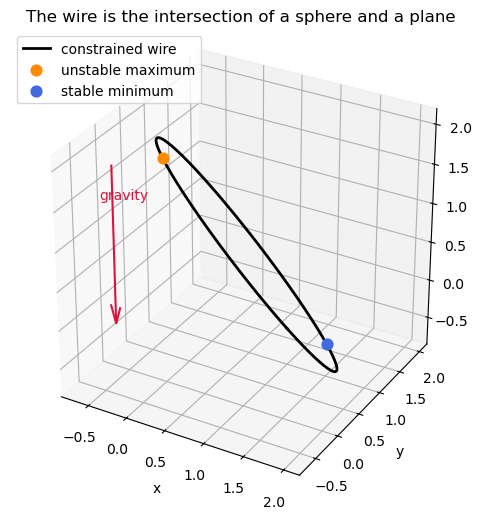

In [10]:
radius = 2.0
centre = radius * np.ones(3) / 3.0
circle_radius = radius * np.sqrt(2.0 / 3.0)
basis_1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
basis_2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)
parameter = np.linspace(0.0, 2.0 * np.pi, 401)
wire = (
    centre[:, None]
    + circle_radius
    * (basis_1[:, None] * np.cos(parameter) + basis_2[:, None] * np.sin(parameter))
)
top = np.array([0.0, 0.0, radius])
bottom = np.array([2.0 * radius / 3.0, 2.0 * radius / 3.0, -radius / 3.0])

fig = plt.figure(figsize=(7, 6))
axis = fig.add_subplot(projection="3d")
axis.plot(*wire, color="black", linewidth=2, label="constrained wire")
axis.scatter(*top, color="darkorange", s=60, label="unstable maximum")
axis.scatter(*bottom, color="royalblue", s=60, label="stable minimum")
axis.quiver(-0.4, -0.4, radius, 0.0, 0.0, -radius, color="crimson", arrow_length_ratio=0.12)
axis.text(-0.5, -0.5, 0.8 * radius, "gravity", color="crimson")
axis.set(xlabel="x", ylabel="y", zlabel="z")
axis.set_box_aspect((1, 1, 1))
axis.set_title("The wire is the intersection of a sphere and a plane")
axis.legend(loc="upper left")
plt.show()

### Numerical solution—and a trap

We now impose the sphere with `NonlinearConstraint` and the plane with `LinearConstraint`. We solve the same minimization twice. The first initial point lies on the side of the wire. The second is exactly the unstable upper equilibrium.

In [11]:
mass_value = 0.25  # kg
gravity = 9.81  # m/s^2
radius = 2.0  # m


def bead_energy(position):
    return mass_value * gravity * position[2]


def bead_energy_gradient(_position):
    return np.array([0.0, 0.0, mass_value * gravity])


sphere = NonlinearConstraint(
    lambda position: np.dot(position, position),
    radius**2,
    radius**2,
    jac=lambda position: 2.0 * position,
)
plane = LinearConstraint(np.ones((1, 3)), [radius], [radius])


def solve_bead(initial_position):
    return minimize(
        bead_energy,
        x0=np.asarray(initial_position, dtype=float),
        jac=bead_energy_gradient,
        method="SLSQP",
        constraints=[sphere, plane],
        options={"ftol": 1.0e-12, "maxiter": 500},
    )


side_result = solve_bead([radius, 0.0, 0.0])
top_result = solve_bead([0.0, 0.0, radius])

for label, result in [("side start", side_result), ("exact top start", top_result)]:
    sphere_residual = np.dot(result.x, result.x) - radius**2
    plane_residual = np.sum(result.x) - radius
    print(label)
    print(f"  success:             {result.success}")
    print(f"  position:            {result.x}")
    print(f"  potential energy:    {result.fun:.8f} J")
    print(f"  constraint residuals: ({sphere_residual:.3e}, {plane_residual:.3e})")

side start
  success:             True
  position:            [ 1.33333333  1.33333333 -0.66666667]
  potential energy:    -1.63500000 J
  constraint residuals: (1.865e-14, 0.000e+00)
exact top start
  success:             True
  position:            [0. 0. 2.]
  potential energy:    4.90500000 J
  constraint residuals: (0.000e+00, 0.000e+00)


Both calls can report success, yet the run initialized exactly at the top remains at the global maximum. The projected first derivative vanishes there, so a first-order local optimizer has satisfied its stopping conditions.

This is not a SciPy defect. It is a limitation of the information supplied to a local solver. Symbolic analysis found both candidates, while physical reasoning and comparison of their energies identified the minimum. For less tractable problems, useful safeguards include multiple starting points, second-order tests, problem-specific bounds, and global methods when justified.

## Reproducibility checks

A numerical result should be checked against the constraints and any known exact result. These assertions turn the comparisons above into executable checks.

In [12]:
expected_bottom = np.array([2.0 * radius / 3.0, 2.0 * radius / 3.0, -radius / 3.0])

assert projectile_result.success
assert np.allclose(projectile_result.x, expected_velocity, rtol=0.0, atol=1.0e-6)
assert abs(np.dot(projectile_result.x, projectile_result.x) - speed**2) < 1.0e-8
assert side_result.success
assert np.allclose(side_result.x, expected_bottom, rtol=0.0, atol=1.0e-6)
assert abs(np.dot(side_result.x, side_result.x) - radius**2) < 1.0e-8
assert abs(np.sum(side_result.x) - radius) < 1.0e-8

print("All symbolic–numerical comparison checks passed.")

All symbolic–numerical comparison checks passed.


## What to take away

- A Lagrange multiplier introduces one additional unknown for each equality constraint.
- The stationary equations encode tangency between objective and constraint level sets.
- Symbolic computation is valuable because it can expose all stationary candidates and parameter dependence.
- Numerical optimization is valuable when the symbolic equations become too large or cannot be solved in closed form.
- Feasibility, physical admissibility, and classification remain your responsibility. `success=True` only means that the solver's stopping conditions were met.
- Bounds and inequality constraints require additional conditions; the general extension is given by the Karush–Kuhn–Tucker conditions.